
**<font color='green' size=5> Полезные ссылки**

Курс по временным рядам https://otexts.com/fpp3/

---
Курс по временным рядов в ВШЭ 2023/24  
http://wiki.cs.hse.ru/Моделирование_временных_рядов_2023/24

ВШЭ ноутбуки семинаров (папки 9 и 10) + видео  
https://github.com/hse-ds/iad-applied-ds/tree/2024/seminars  
https://www.youtube.com/watch?v=ffGdPKUVBd4&list=PLEwK9wdS5g0rWzgNYRIO270UtTvvvJThY&index=65

Вводный курс по ML  
https://www.dmitrymakarov.ru/intro/time-series-20/

---

Страница и доки библиотеки Etna  
https://github.com/tinkoff-ai/etna  
https://etna-docs.netlify.app/tutorials/get_started

Библиотека Pytorch Forecasting  
https://pytorch-forecasting.readthedocs.io/en/stable/getting-started.html

Библиотека StatsForecast  
https://nixtlaverse.nixtla.io/statsforecast/index.html

---
соревнования по временным рядам https://forecasters.org/resources/time-series-data/

---
Критери Дики Фуллера https://www.youtube.com/watch?v=D3AKcOun29s

---
Ниже главы из книги: https://education.yandex.ru/handbook/ml

https://education.yandex.ru/handbook/ml/article/vremennye-ryady

https://education.yandex.ru/handbook/ml/article/analitika-vremennyh-ryadov

https://education.yandex.ru/handbook/ml/article/modeli-vida-arima

# **<font color='green' size=6> Загрузка и импорт библиотек**

In [11]:
# используется для автоматического подбора оптимальных параметров модели ARIMA
#!pip install pmdarima -q

In [12]:
# пакет tsfresh используется для извлечения признаков из временных рядов
#!pip install tsfresh -q

In [13]:
#!pip install prophet

In [14]:
#!pip install seaborn

In [15]:
#pip install scipy==1.13.0 statsmodels==0.14.1 pmdarima==2.0.4

In [16]:
import pmdarima

In [17]:
import numpy as np
import pandas as pd
import scipy
#import pmdarima

In [18]:
print(np.__version__)
print(pd.__version__)
print(scipy.__version__)

1.26.4
2.3.0
1.13.0


In [19]:
pip check

No broken requirements found.
Note: you may need to restart the kernel to use updated packages.


In [20]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error as MSE

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

from scipy.stats import norm

# from tsfresh.utilities.dataframe_functions import make_forecasting_frame
# Импортируем функцию roll_time_series из библиотеки from tsfresh.utilities.dataframe_functions
# from tsfresh.utilities.dataframe_functions import roll_time_series


from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (23,9)

In [21]:
# Загружаем данные

df = sns.load_dataset('flights')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [22]:
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [23]:
df[['year', 'month']] = df[['year', 'month']].astype('str')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        144 non-null    object
 1   month       144 non-null    object
 2   passengers  144 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 3.5+ KB


In [24]:
df['date'] = df['year'] + "-" + df["month"]


df.head()

,year,month,passengers,date
0,1949,Jan,112,1949-Jan
1,1949,Feb,118,1949-Feb
2,1949,Mar,132,1949-Mar
3,1949,Apr,129,1949-Apr
4,1949,May,121,1949-May


In [25]:
df['date'] = pd.to_datetime(df['date'])
df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5500\2227006722.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


,year,month,passengers,date
0,1949,Jan,112,1949-01-01
1,1949,Feb,118,1949-02-01
2,1949,Mar,132,1949-03-01
3,1949,Apr,129,1949-04-01
4,1949,May,121,1949-05-01


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    object        
 1   month       144 non-null    object        
 2   passengers  144 non-null    int64         
 3   date        144 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 4.6+ KB


In [27]:
df = df.set_index(df.date)
df.head()

,year,month,passengers,date
date,,,,
1949-01-01,1949,Jan,112,1949-01-01
1949-02-01,1949,Feb,118,1949-02-01
1949-03-01,1949,Mar,132,1949-03-01
1949-04-01,1949,Apr,129,1949-04-01
1949-05-01,1949,May,121,1949-05-01


In [28]:
df = df.drop(columns=['year', 'month', 'date'])
df.head()

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


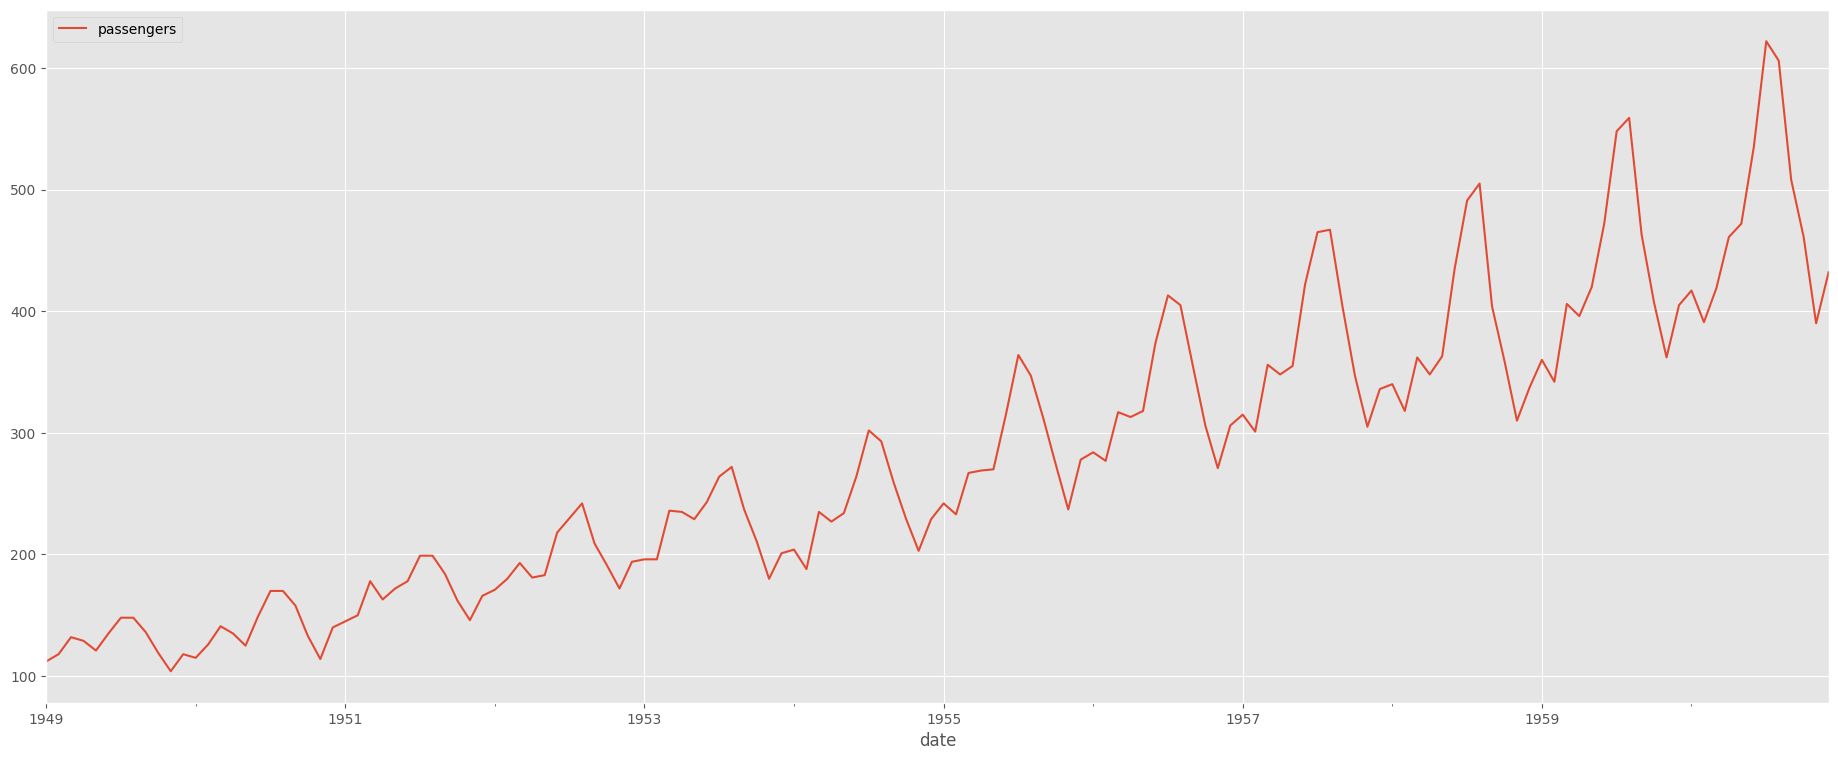

In [29]:
_ = df.plot()

# **<font color='green' size=6>  Разделение на трейн и тест**

In [30]:
# размер тестовой выборки
test_size = int(len(df) * 0.2)

# тренировочная выборка
train = df[:-test_size]

# тестовая выборка
test = df[-test_size-1:]

# **<font color='green' size=6> ARMA, ARIMA, SARIMA, SARIMAX**

Доки по прогнозированию в statsmodels  
https://www.statsmodels.org/stable/examples/notebooks/generated/statespace_forecasting.html

 - `ARMA` (Autoregressive Moving Average) - модель, объединяющая авторегрессионную (AR) и модель скользящего среднего (MA) компоненты.  
 Используется для стационарных временных рядов без тренда и сезонности.

 - `ARIMA` (Autoregressive Integrated Moving Average) - расширение `ARMA`, которое включает дополнительную интегрированную (I) компоненту для обработки нестационарных рядов с трендом.  
 Применяется для нестационарных рядов после их предварительного приведения к стационарности путем взятия разностей.

 - `SARIMA` (Seasonal ARIMA) - сезонная версия `ARIMA`, которая учитывает периодические сезонные колебания в данных.  
 Используется для временных рядов с ярко выраженной сезонностью.

 - `SARIMAX` (Seasonal ARIMAX) - расширение `SARIMA`, которое включает дополнительные регрессионные переменные (X) для учета влияния внешних факторов на временной ряд.  
 Подходит для сложных моделей с сезонностью и экзогенными переменными.

## SARIMA

**S** - Seasonal

**AR** - Auto-Regressive

**I** - Integrated

**MA** - Moving Average


- p: The number of lag observations included in the model, also called the lag order.
- d: The number of times that the raw observations are differenced, also called the degree of differencing.
- q: The size of the moving average window, also called the order of moving average.

**X** - with eXogenous factors

https://analyticsindiamag.com/complete-guide-to-sarimax-in-python-for-time-series-modeling/

**Плюсы:**
    
- высокая точность предсказания
- учитвыает тренд и сезонность (SARIMA)
- учитывает внешние факторы (SARIMAX)

**Минусы:**

- долго подбирать гиперпараметры
- нужно понимать что такое диффиренцирование, авторегрессия и проч.

## Pmdarima - Обучение модели с поиском параметров

In [31]:
%%time
# Находим оптимальные параметры для ARIMA модели с сезонной составляющей:
# p - порядок авторегрессии (AR)
# d - порядок разности (I)
# q - порядок скользящего среднего (MA)
# P - сезонный порядок авторегрессии
# D - сезонный порядок разности
# Q - сезонный порядок скользящего среднего

# Используем auto_arima для автоматического подбора параметров ARIMA
model_aa = auto_arima(train["passengers"],
                    start_p=0,     # начальное значение p
                    start_q=0,     # начальное значение q
                    max_p=3,       # максимальное значение p
                    max_q=3,       # максимальное значение q
                    m=12,          # периодичность сезонности (12 месяцев)
                    start_P=0,     # начальное значение сезонного P
                    seasonal=True, # учитывать сезонность
                    d=None,       # автоматически определить порядок дифференцирования d
                    D=None,       # автоматически определить сезонный порядок дифференцирования D
                    trace=True,   # выводить процесс подбора параметров
                    error_action='ignore',     # игнорировать ошибки
                    suppress_warnings=True,    # подавлять предупреждения
                    stepwise=True) # использовать пошаговый алгоритм для ускорения подбора

c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finit

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=765.377, Time=0.06 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=765.723, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=764.756, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=765.328, Time=0.08 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=764.138, Time=0.02 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=764.944, Time=0.08 sec


c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(1,1,1)[12]             : AIC=766.619, Time=0.14 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=765.206, Time=0.04 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=762.550, Time=0.11 sec


c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(1,1,1)(1,1,1)[12]             : AIC=767.126, Time=0.25 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=764.631, Time=0.14 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=766.465, Time=0.06 sec


c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(0,1,0)[12]             : AIC=766.346, Time=0.07 sec
 ARIMA(0,1,2)(0,1,0)[12]             : AIC=766.167, Time=0.04 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=763.479, Time=0.13 sec


c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,1,0)[12] intercept   : AIC=766.438, Time=0.11 sec

Best model:  ARIMA(1,1,1)(0,1,0)[12]          
Total fit time: 1.727 seconds
CPU times: total: 6.45 s
Wall time: 1.74 s


c:\Users\Admin\Documents\Python\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


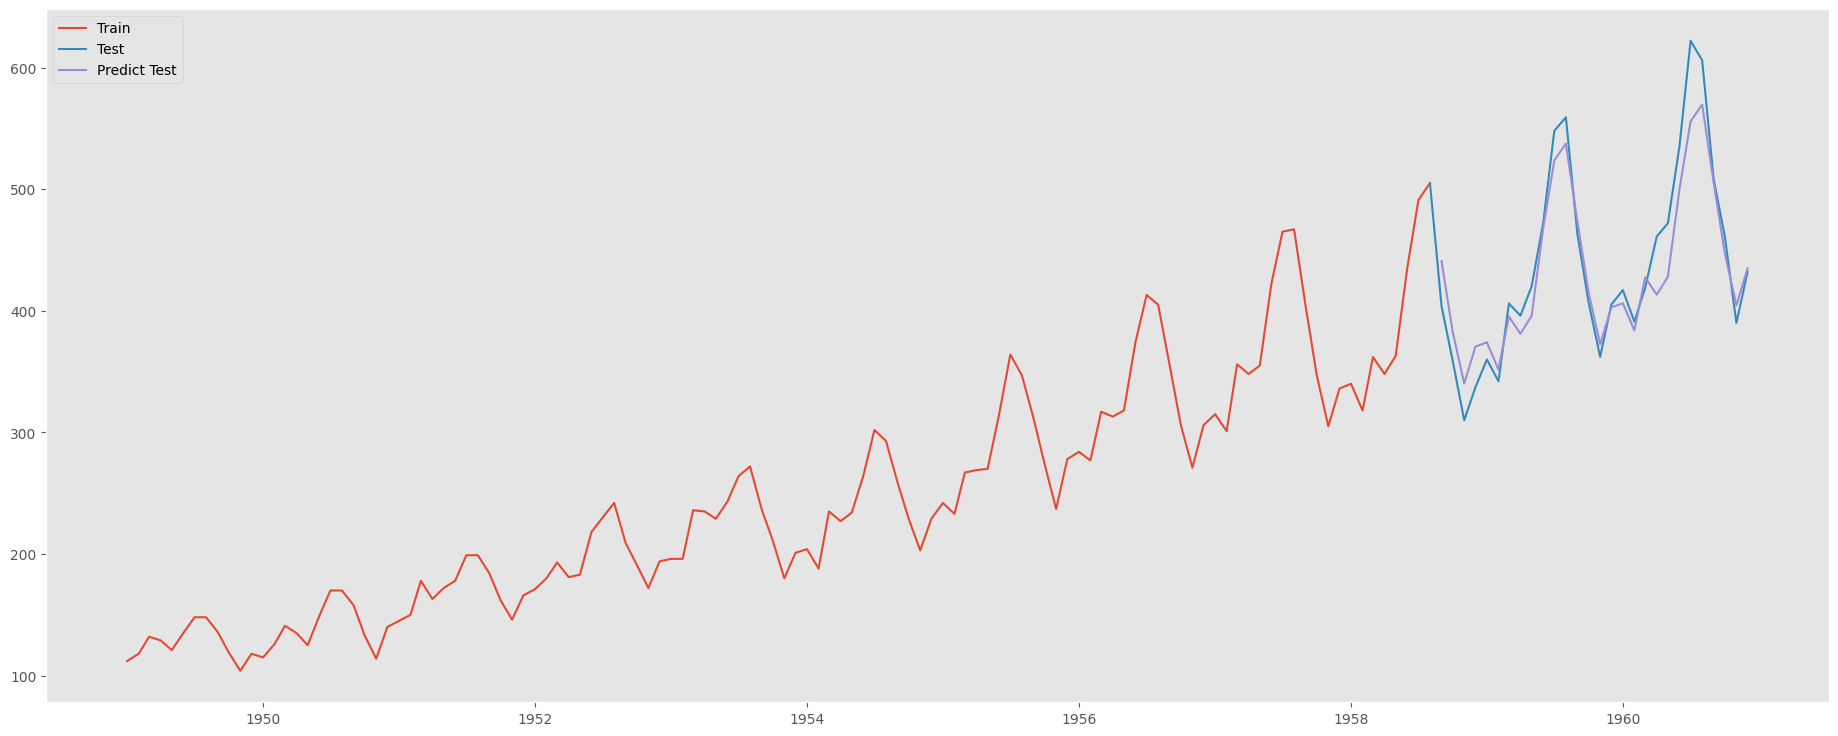

In [32]:
# получение предсказаний
predict = model_aa.predict(n_periods=test_size)

# отрисовка обучающей выборки, тестовой и предсказанной тестовой
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(predict, label='Predict Test')
plt.grid()
plt.legend()
plt.show()

In [33]:
model_aa.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  116
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 12)   Log Likelihood                -378.275
Date:                             Tue, 01 Jul 2025   AIC                            762.550
Time:                                     21:32:48   BIC                            770.454
Sample:                                 01-01-1949   HQIC                           765.752
                                      - 08-01-1958                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8014      0.081      9.916      0.000       0.643       0.960
ma.L1         -0.9731      0.045    -21.593      0.000      -1.061      -0.885
sigma2        89.8590     12.866      6.984      0.000      64.642     115.076
===================================================================================
Ljung-Box (L1) (Q):                   1.00   Jarque-Bera (JB):                 1.95
Prob(Q):                              0.32   Prob(JB):                         0.38
Heteroskedasticity (H):               0.87   Skew:                             0.32
Prob(H) (two-sided):                  0.69   Kurtosis:                         2.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Model: SARIMAX(1, 1, 1)x(0, 1, [], 12) - параметры модели:

ARIMA(1, 1, 1) - модель авторегрессии (AR) порядка 1, интегрированная (I) порядок 1 и скользящего среднего (MA) порядка 1.


(0, 1, [], 12) - сезонный компонент с порядком 0 для AR, порядком 1 для I, и порядком 0 для MA, с сезонностью в 12 периодов (например, месяцы в годовом цикле).


Heteroskedasticity (H): 0.87 - тест на гетероскедастичность (разную дисперсию остатков).

Prob(H) (two-sided): 0.68 - p-значение для теста. Значение больше 0.05 указывает на отсутствие гетероскедастичности.



# **<font color='green' size=6> Разделение на компоненты**

Функция seasonal_decompose из библиотеки statsmodels (sm.tsa.seasonal_decompose) используется для декомпозиции временного ряда на три основные компоненты:

Тренд (Trend) — долгосрочное направление изменения данных.

Сезонность (Seasonal) — повторяющиеся паттерны (например, ежемесячные или квартальные колебания).

Остаток (Residual) — случайные колебания, не объяснённые трендом и сезонностью.

Основные параметры:

- "additive" (по умолчанию) — если сезонность не зависит от уровня ряда.

- "multiplicative" — если сезонность усиливается с ростом ряда.

## **<font color='green' size=5> Seasonal_decompose**

In [34]:
data = df.reset_index()
data.columns = ["date", "value"]
data = data.set_index(['date'])

In [35]:
data

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


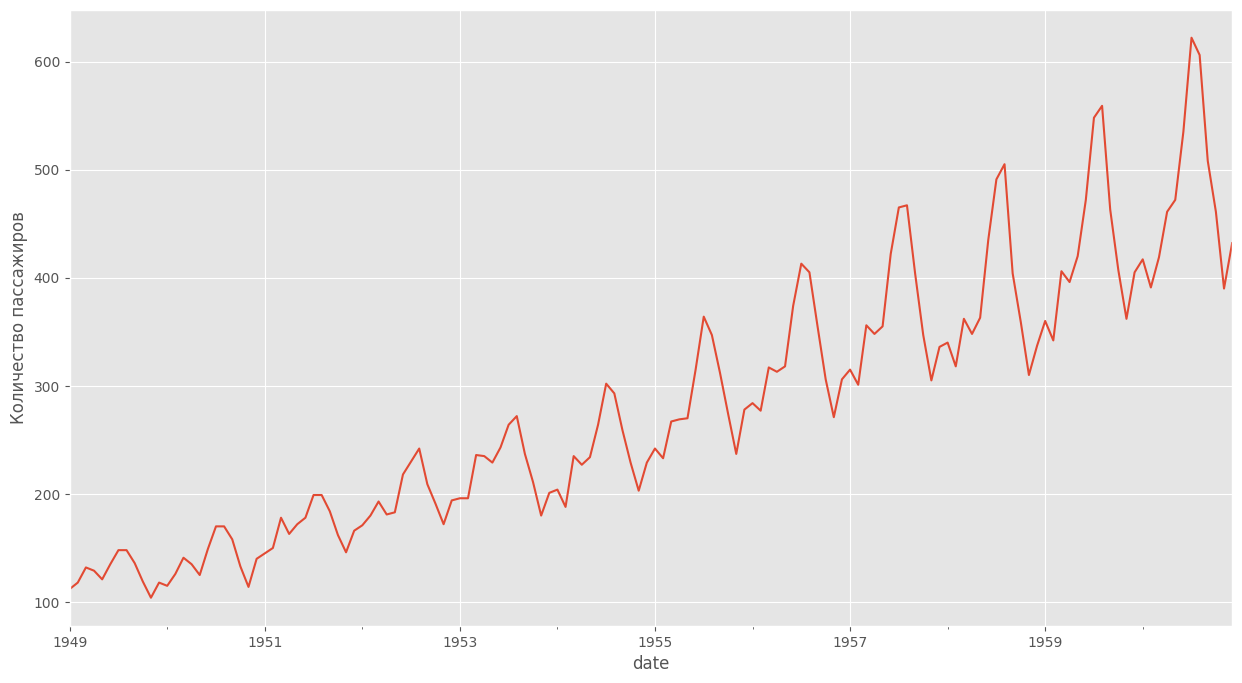

In [36]:
plt.figure(figsize=(15,8))
data['value'].plot()
plt.ylabel('Количество пассажиров')
plt.show()

<Figure size 1500x800 with 0 Axes>

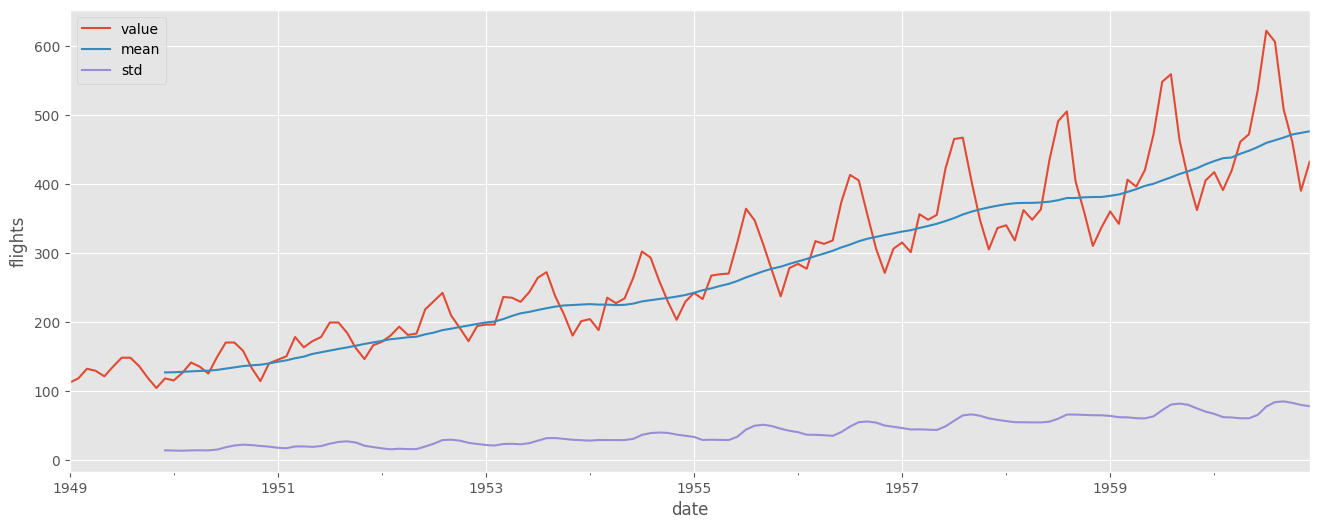

In [37]:
plt.figure(figsize=(15,8))
data['mean'] = data['value'].rolling(12).mean()
data['std'] = data['value'].rolling(12).std()
data.plot(figsize=(16, 6))
plt.ylabel('flights')
plt.show()

`sm.tsa.seasonal_decompose` автоматически вычисляет тренд и сезонность, используя методы, такие как скользящее среднее для тренда и средние сезонные значения для сезонности, и предоставляет их в виде графиков для дальнейшего анализа.

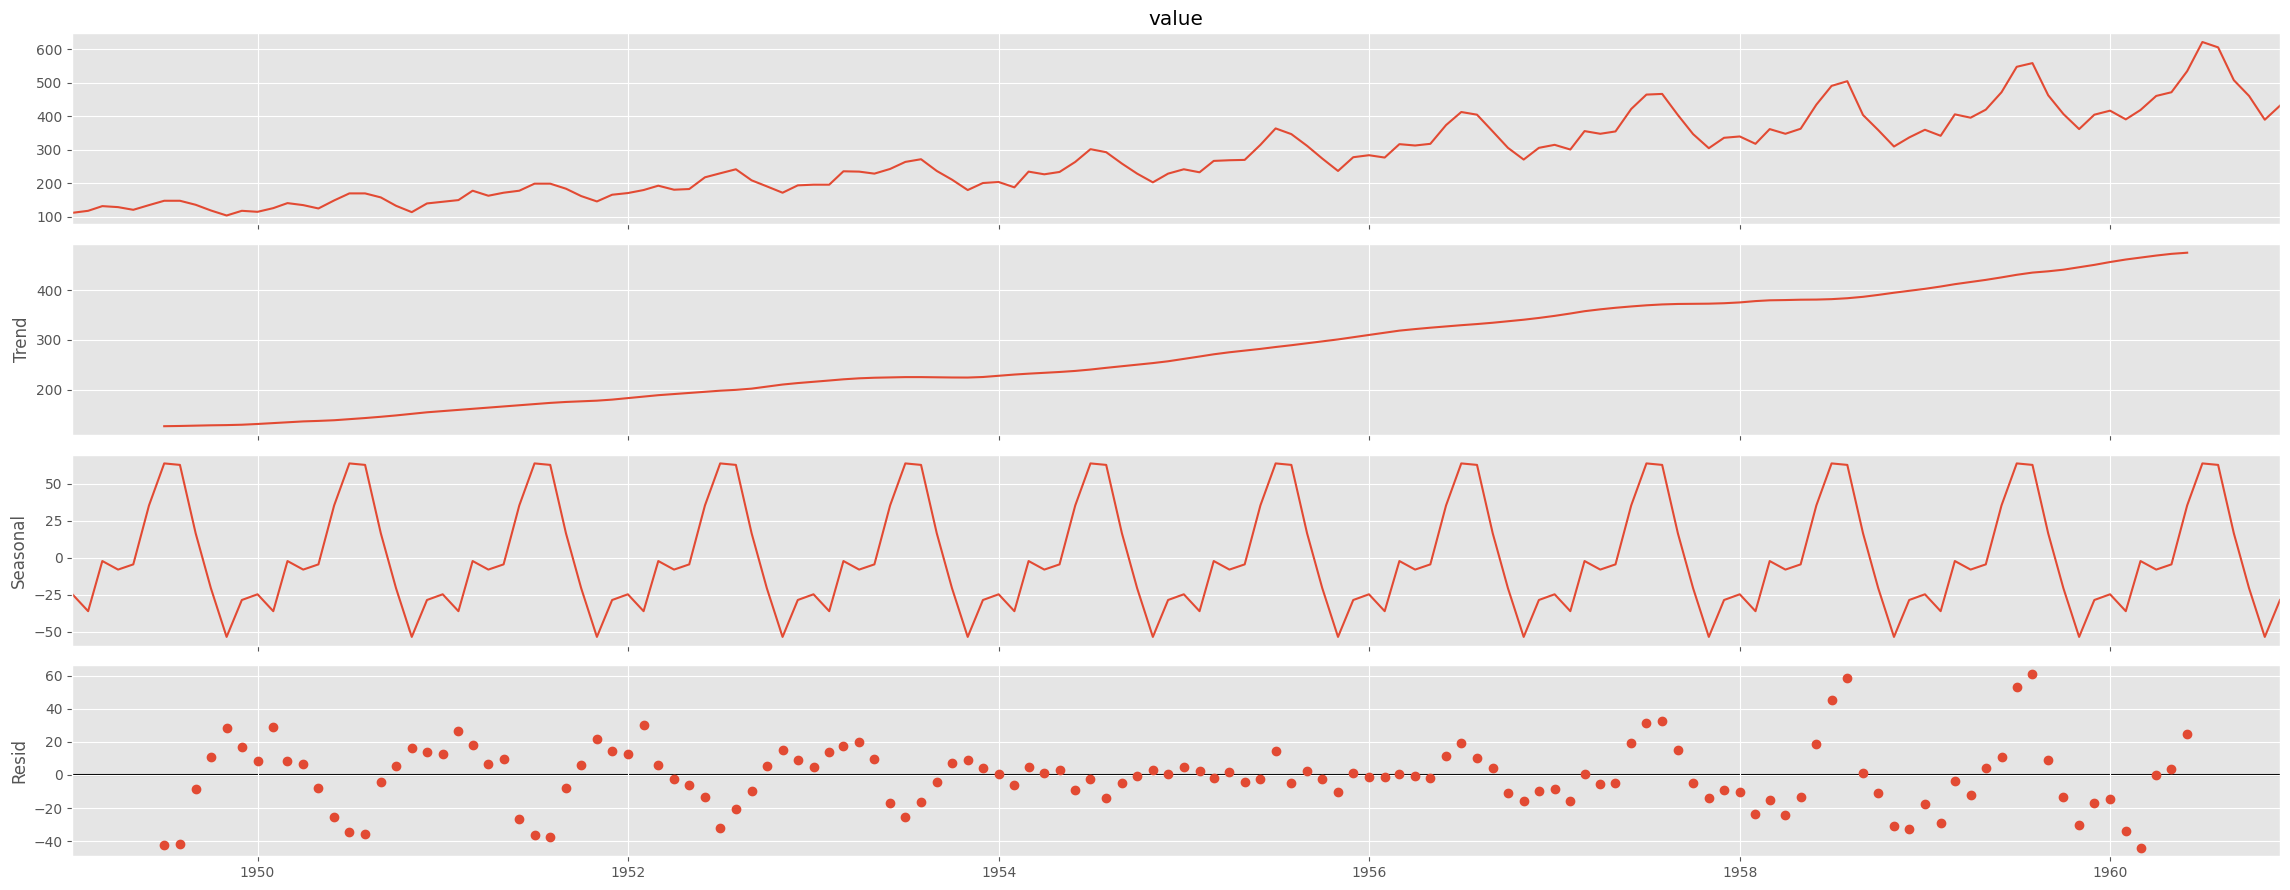

In [38]:
sm.tsa.seasonal_decompose(data['value']).plot()
plt.show()

## **<font color='green' size=5> Prophet**

Страница Prophet  
https://github.com/facebook/prophet

Доки Prophet  
https://facebook.github.io/prophet/docs/quick_start.html

In [39]:
df_prophet = data['value'].reset_index().copy()
df_prophet.columns = ['ds', 'y']
df_prophet.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [40]:
train_prophet = df_prophet[:-12]
test_prophet = df_prophet[-12:]

In [41]:

model = Prophet(seasonality_mode='additive', )

model.fit(train_prophet)
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

21:32:49 - cmdstanpy - INFO - Chain [1] start processing
21:33:02 - cmdstanpy - INFO - Chain [1] done processing


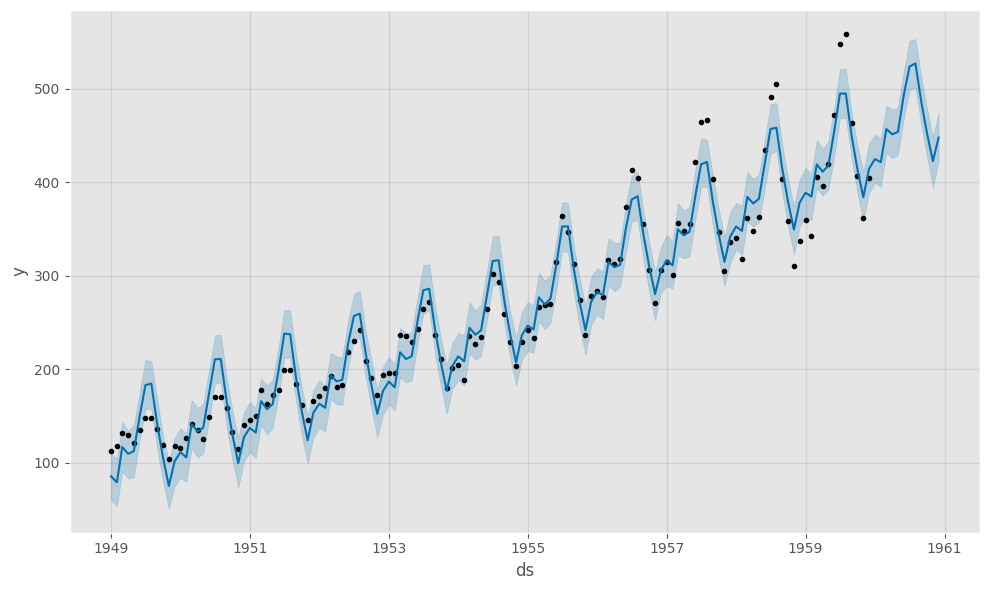

In [42]:
ax = model.plot(forecast)

In [43]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,109.172700,60.352858,110.387130,109.172700,109.172700,-23.941985,-23.941985,-23.941985,-23.941985,-23.941985,-23.941985,0.0,0.0,0.0,85.230715
1,1949-02-01,111.325317,53.184279,104.008837,111.325317,111.325317,-32.466048,-32.466048,-32.466048,-32.466048,-32.466048,-32.466048,0.0,0.0,0.0,78.859270
2,1949-03-01,113.269617,90.469870,143.277443,113.269617,113.269617,3.286820,3.286820,3.286820,3.286820,3.286820,3.286820,0.0,0.0,0.0,116.556437
3,1949-04-01,115.422234,82.744631,133.955255,115.422234,115.422234,-6.123591,-6.123591,-6.123591,-6.123591,-6.123591,-6.123591,0.0,0.0,0.0,109.298644
4,1949-05-01,117.505413,84.523285,140.020451,117.505413,117.505413,-5.272997,-5.272997,-5.272997,-5.272997,-5.272997,-5.272997,0.0,0.0,0.0,112.232416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-08-01,467.919959,501.672937,553.390487,467.580925,468.167055,59.363904,59.363904,59.363904,59.363904,59.363904,59.363904,0.0,0.0,0.0,527.283863
140,1960-09-01,470.938431,461.365716,512.536963,470.536158,471.231496,15.094952,15.094952,15.094952,15.094952,15.094952,15.094952,0.0,0.0,0.0,486.033383
141,1960-10-01,473.859533,427.302883,479.145479,473.380670,474.208337,-21.475291,-21.475291,-21.475291,-21.475291,-21.475291,-21.475291,0.0,0.0,0.0,452.384241
142,1960-11-01,476.878004,394.359334,448.780994,476.324791,477.282707,-54.330633,-54.330633,-54.330633,-54.330633,-54.330633,-54.330633,0.0,0.0,0.0,422.547372


In [44]:
p_prediction = test_prophet.set_index('ds').join(forecast.set_index('ds')[['yhat']][-12:])
p_prediction

,y,yhat
ds,,
1960-01-01,417,424.857856
1960-02-01,391,421.466174
1960-03-01,419,457.006066
1960-04-01,461,451.358247
1960-05-01,472,453.882950
1960-06-01,535,493.714142
1960-07-01,622,523.838184
1960-08-01,606,527.283863
1960-09-01,508,486.033383


In [45]:
mse = MSE(p_prediction['y'], p_prediction['yhat'])
print('Prophet')
print('MAPE:', MAPE(p_prediction['y'], p_prediction['yhat']))
print('RMSE:', mse**.5)
print('MSE:', mse)

Prophet
MAPE: 0.0661426159063319
RMSE: 43.06896684410102
MSE: 1854.9359050182732


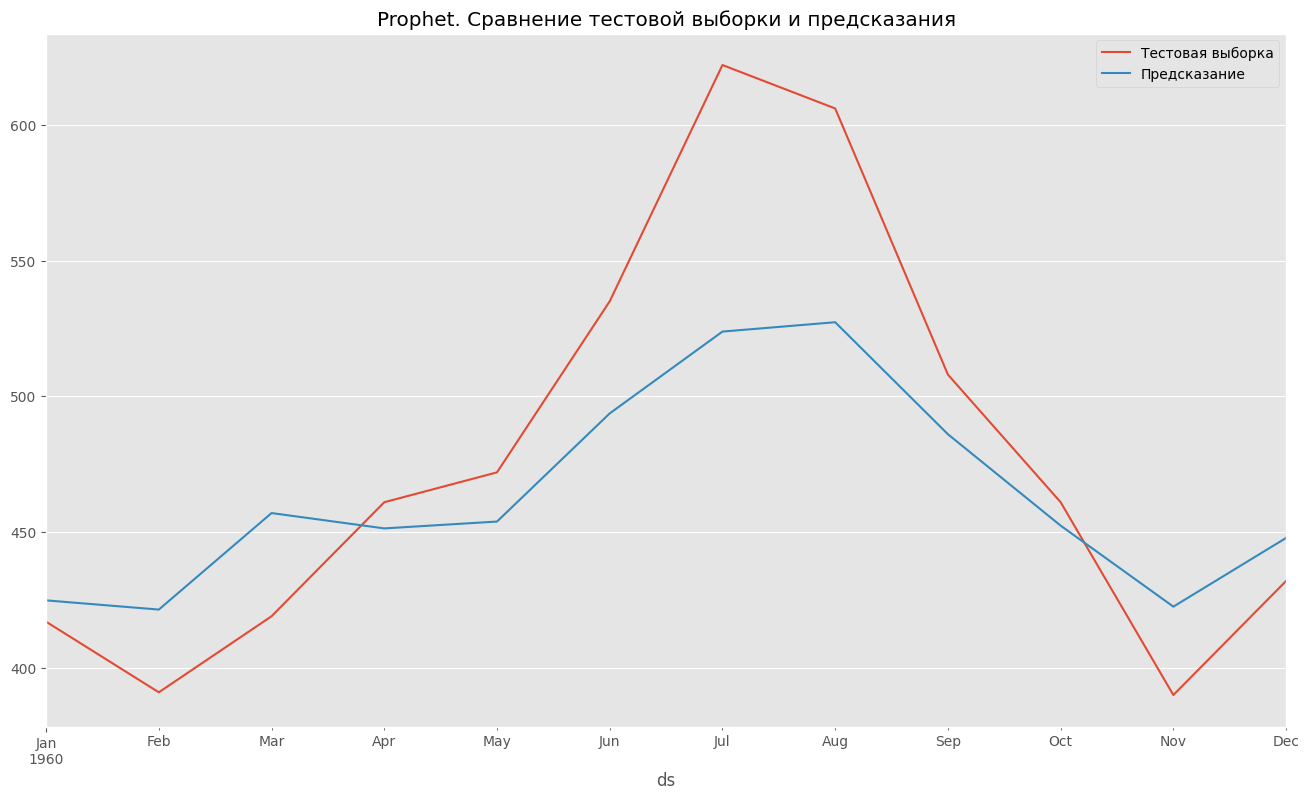

In [46]:
ax1 = p_prediction['y'].plot(legend=True, title='Prophet. Сравнение тестовой выборки и предсказания')
ax2 = p_prediction['yhat'].plot(figsize=(16,9), legend=True) \
  .legend(['Тестовая выборка', 'Предсказание'])

In [47]:
prediction = forecast.set_index('ds')[['yhat']]
prediction[-12:]

,yhat
ds,
1960-01-01,424.857856
1960-02-01,421.466174
1960-03-01,457.006066
1960-04-01,451.358247
1960-05-01,453.882950
1960-06-01,493.714142
1960-07-01,523.838184
1960-08-01,527.283863
1960-09-01,486.033383


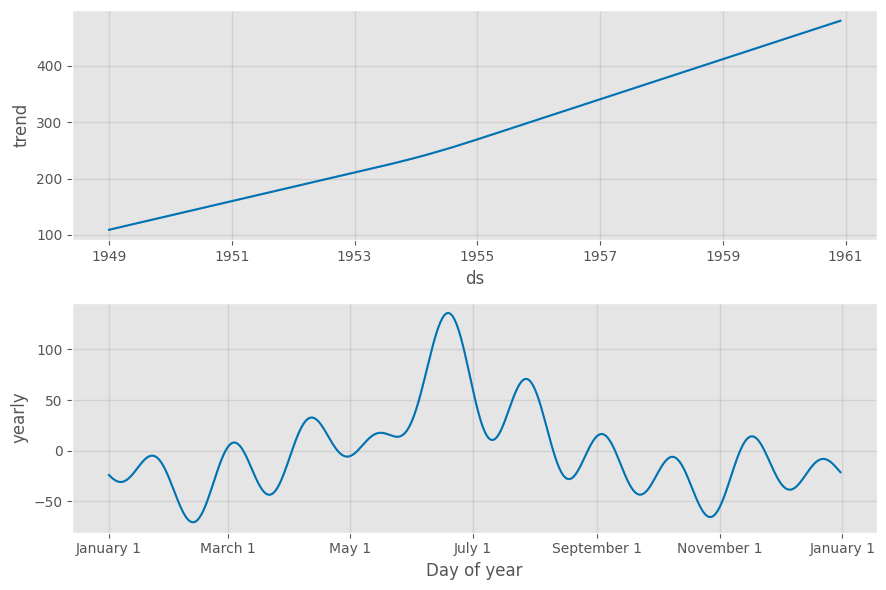

In [48]:
fig = model.plot_components(forecast)

Change points

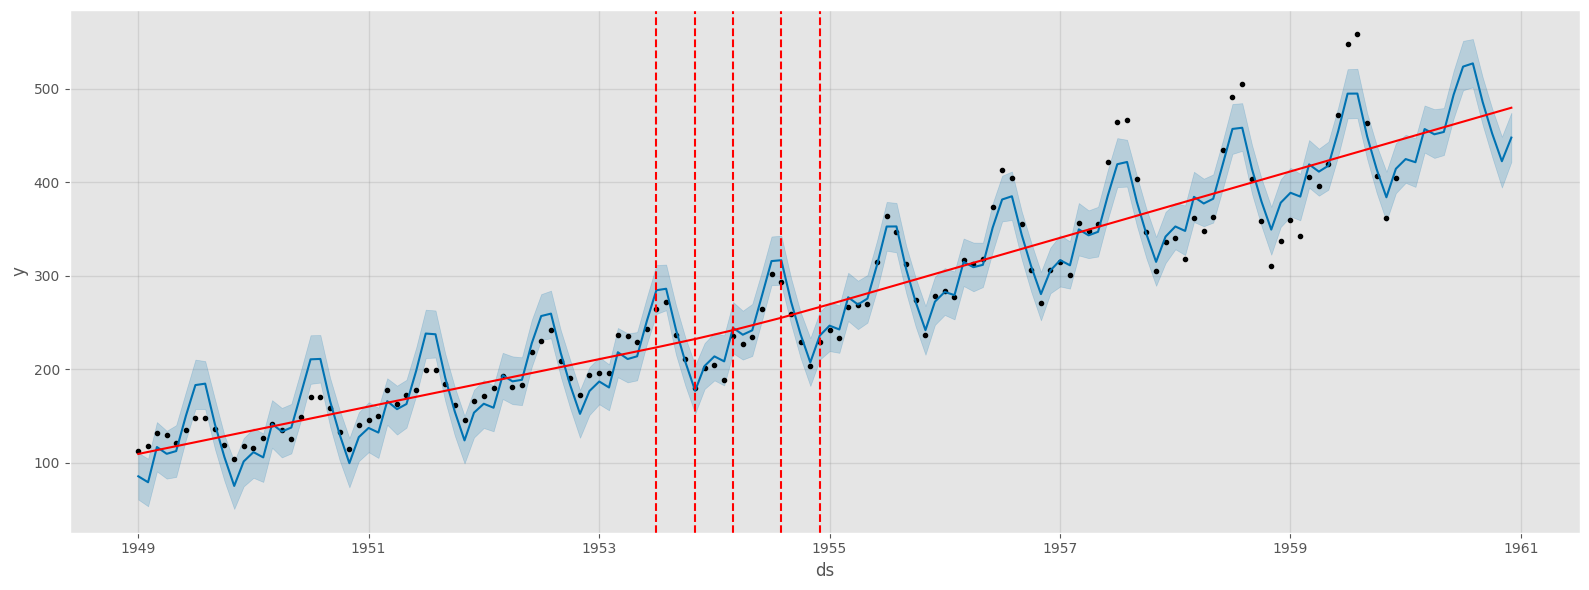

In [49]:
fig = model.plot(forecast, figsize=(16, 6))
a = add_changepoints_to_plot(fig.gca(), model, forecast)


In [50]:
model.changepoints

4     1949-05-01
8     1949-09-01
12    1950-01-01
17    1950-06-01
21    1950-10-01
25    1951-02-01
29    1951-06-01
33    1951-10-01
37    1952-02-01
42    1952-07-01
46    1952-11-01
50    1953-03-01
54    1953-07-01
58    1953-11-01
62    1954-03-01
67    1954-08-01
71    1954-12-01
75    1955-04-01
79    1955-08-01
83    1955-12-01
87    1956-04-01
92    1956-09-01
96    1957-01-01
100   1957-05-01
104   1957-09-01
Name: ds, dtype: datetime64[ns]

In [51]:
model = Prophet()
model.add_country_holidays(country_name='US')
model.fit(train_prophet)

future = model.make_future_dataframe(periods=test_size)
forecast = model.predict(future)

21:33:03 - cmdstanpy - INFO - Chain [1] start processing
21:33:03 - cmdstanpy - INFO - Chain [1] done processing


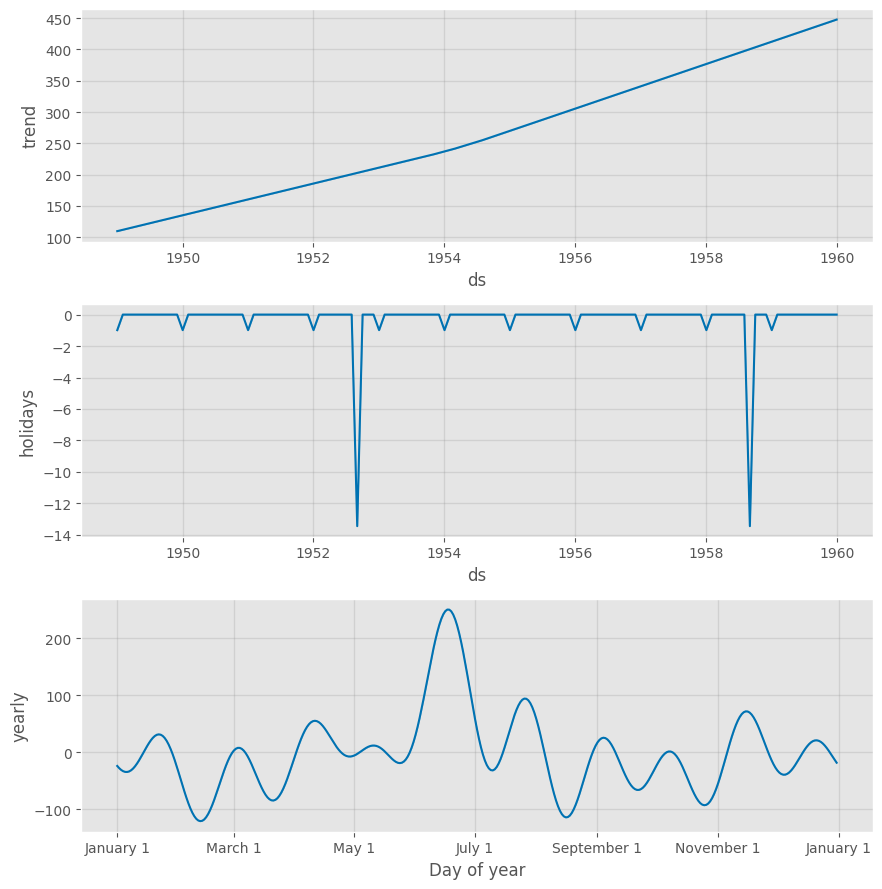

In [52]:
fig = model.plot_components(forecast)